
## Importig Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_percentage_error,
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries imported successfully.")

Libraries imported successfully.


---
## Loading Clean Fact Tables (from SQL ETL)


In [3]:
purchase = pd.read_csv("CleanData/fact_purchase_clean.csv") 
inventory = pd.read_csv("CleanData/fact_inventory_clean.csv")
sales_fc  = pd.read_csv("CleanData/Fact_Sales_Forecast_clean.csv")
logistics = pd.read_csv("CleanData/fact_logistics_clean.csv")
suppliers = pd.read_csv("ExcelFiles/suppliers.csv")
calendar  = pd.read_csv("ExcelFiles/calendar.csv")

print("Clean fact tables loaded:")
print(f"  purchase  : {len(purchase):,} rows | columns: {list(purchase.columns)}")
print(f"  inventory : {len(inventory):,} rows | columns: {list(inventory.columns)}")
print(f"  sales_fc  : {len(sales_fc):,} rows | columns: {list(sales_fc.columns)}")
print("\nDimension tables loaded:")
print(f"  calendar  : {len(calendar):,} rows")
print(f"  suppliers : {len(suppliers):,} rows")

Clean fact tables loaded:
  purchase  : 795 rows | columns: ['purchase_fact_key', 'product_key', 'supplier_key', 'order_date_key', 'promised_date_key', 'actual_date_key', 'quantity']
  inventory : 120 rows | columns: ['inventory_key', 'product_key', 'warehouse_key', 'supplier_key', 'current_stock', 'reorder_level']
  sales_fc  : 2,000 rows | columns: ['sales_forecast_key', 'product_key', 'date_key', 'historical_demand', 'forecasted_demand']

Dimension tables loaded:
  calendar  : 2,192 rows
  suppliers : 10 rows


---
## Decoding Surrogate Keys → Real Values

our clean tables use integer surrogate keys (e.g. `order_date_key = 5`), joining them back to the dimension tables to get real dates and supplier names.


In [5]:
# ── Build dim_date: row position becomes the date_key ───────────────────
calendar['date_key'] = range(1, len(calendar) + 1)
calendar['full_date'] = pd.to_datetime(calendar['date'], dayfirst=True)

dim_date = calendar[['date_key', 'full_date', 'year', 'month', 'quarter', 'week']].copy()

# ── Build dim_supplier: row position becomes the supplier_key ────────────
suppliers['supplier_key'] = range(1, len(suppliers) + 1)
dim_supplier = suppliers[['supplier_key', 'supplier_id', 'supplier_name', 'rating']].copy()

print("dim_date sample:")
print(dim_date.head(3).to_string(index=False))
print("\ndim_supplier:")
print(dim_supplier.to_string(index=False))

dim_date sample:
 date_key  full_date  year  month  quarter  week
        1 2019-01-01  2019      1        1     1
        2 2019-01-02  2019      1        1     1
        3 2019-01-03  2019      1        1     1

dim_supplier:
 supplier_key supplier_id supplier_name  rating
            1        S001    Supplier_1    4.20
            2        S002    Supplier_2    4.42
            3        S003    Supplier_3    3.04
            4        S004    Supplier_4    4.94
            5        S005    Supplier_5    4.66
            6        S006    Supplier_6    3.42
            7        S007    Supplier_7    3.36
            8        S008    Supplier_8    3.37
            9        S009    Supplier_9    3.61
           10        S010   Supplier_10    4.05


In [6]:
# ── Decoding purchase: join date keys 3 times to get real dates ───────────
purchase_decoded = (
    purchase
    .merge(dim_date.rename(columns={'date_key':'order_date_key',    'full_date':'order_date',    'year':'order_year',    'month':'order_month',    'quarter':'order_quarter', 'week':'order_week'}),    on='order_date_key',    how='left')
    .merge(dim_date[['date_key','full_date']].rename(columns={'date_key':'promised_date_key', 'full_date':'promised_date'}), on='promised_date_key', how='left')
    .merge(dim_date[['date_key','full_date']].rename(columns={'date_key':'actual_date_key',   'full_date':'actual_date'}),   on='actual_date_key',   how='left')
    .merge(dim_supplier[['supplier_key','supplier_id','supplier_name','rating']], on='supplier_key', how='left')
)

# Compute real delivery metrics
purchase_decoded['lead_time_days'] = (purchase_decoded['actual_date']   - purchase_decoded['order_date']).dt.days
purchase_decoded['delay_days']     = (purchase_decoded['actual_date']   - purchase_decoded['promised_date']).dt.days
purchase_decoded['delay_flag']     = (purchase_decoded['delay_days'] > 0).astype(int)

print(f"Purchase decoded: {purchase_decoded.shape}")
print(f"Delayed orders  : {purchase_decoded['delay_flag'].sum()} / {len(purchase_decoded)}")
print(f"Avg lead time   : {purchase_decoded['lead_time_days'].mean():.2f} days")
print(f"Avg delay days  : {purchase_decoded['delay_days'].mean():.2f} days")
print()
print(purchase_decoded[['supplier_name','order_date','actual_date','lead_time_days','delay_days','delay_flag']].head(4).to_string(index=False))

Purchase decoded: (795, 20)
Delayed orders  : 576 / 795
Avg lead time   : 11.78 days
Avg delay days  : 3.35 days

supplier_name order_date actual_date  lead_time_days  delay_days  delay_flag
   Supplier_9 2019-01-02  2019-01-24              22           8           1
   Supplier_4 2019-01-04  2019-01-17              13           3           1
   Supplier_5 2019-01-05  2019-01-15              10           1           1
   Supplier_3 2019-01-06  2019-01-15               9           5           1


In [7]:
# ── Decode sales_forecast: join date_key once ───────────────────────────
sales_decoded = (
    sales_fc
    .merge(dim_date[['date_key','full_date','year','month','quarter']],
           on='date_key', how='left')
    .sort_values(['product_key', 'full_date'])
    .reset_index(drop=True)
)

# Lag features per product
sales_decoded['demand_lag1']  = sales_decoded.groupby('product_key')['historical_demand'].shift(1)
sales_decoded['demand_roll3'] = sales_decoded.groupby('product_key')['historical_demand'].transform(
    lambda x: x.shift(1).rolling(3).mean())
sales_decoded = sales_decoded.dropna(subset=['demand_lag1','demand_roll3'])

print(f"Sales forecast decoded: {sales_decoded.shape}")
print(sales_decoded[['product_key','full_date','year','month','historical_demand','demand_lag1']].head(4).to_string(index=False))

Sales forecast decoded: (1910, 11)
 product_key  full_date  year  month  historical_demand  demand_lag1
           1 2019-05-13  2019      5                547       1283.0
           1 2019-09-03  2019      9                510        547.0
           1 2019-11-28  2019     11                549        510.0
           1 2020-01-22  2020      1               1088        549.0


In [8]:
# ── Decode inventory: join supplier_key ─────────────────────────────────
inventory_decoded = inventory.merge(
    dim_supplier[['supplier_key','supplier_id','supplier_name','rating']],
    on='supplier_key', how='left')

# Enrich inventory with avg lead time and avg demand per product
lead_by_prod   = purchase_decoded.groupby('product_key')['lead_time_days'].mean().reset_index()
lead_by_prod.columns = ['product_key','avg_lead_time']

demand_by_prod = sales_decoded.groupby('product_key')['historical_demand'].agg(['mean','std']).reset_index()
demand_by_prod.columns = ['product_key','avg_demand','demand_std']

inventory_decoded = (inventory_decoded
    .merge(lead_by_prod,   on='product_key', how='left')
    .merge(demand_by_prod, on='product_key', how='left'))

inventory_decoded['stockout_flag'] = (inventory_decoded['current_stock'] < inventory_decoded['reorder_level']).astype(int)
inventory_decoded['stock_ratio']   = inventory_decoded['current_stock'] / inventory_decoded['reorder_level']
inventory_decoded['days_of_cover'] = (inventory_decoded['current_stock'] /
                                      inventory_decoded['avg_demand'].replace(0, np.nan))
inventory_decoded = inventory_decoded.dropna()

print(f"Inventory decoded: {inventory_decoded.shape}")
print(f"Stockout risk    : {inventory_decoded['stockout_flag'].sum()} / {len(inventory_decoded)} SKU-warehouse combos")
print(inventory_decoded[['product_key','warehouse_key','supplier_name','current_stock','reorder_level','stockout_flag']].head(4).to_string(index=False))

Inventory decoded: (120, 15)
Stockout risk    : 14 / 120 SKU-warehouse combos
 product_key  warehouse_key supplier_name  current_stock  reorder_level  stockout_flag
           1              1    Supplier_9            867            191              0
           1              2    Supplier_9           1161            212              0
           1              3    Supplier_9            386            160              0
           1              4    Supplier_9            613             66              0


---
## Use Case 1: Demand Forecasting (Regression)

**Goal:** Predict `historical_demand` using time features + lag features from the clean sales forecast table.


## Defining Features & Target

In [11]:

features_uc1 = ['month','quarter','year','product_key','demand_lag1','demand_roll3']
X_fc = sales_decoded[features_uc1]
y_fc = sales_decoded['historical_demand']

## Time-Based Split

In [16]:
# Time-based split (NO random split)
split_idx = int(len(sales_decoded) * 0.8)

X_train_fc, X_test_fc = X_fc.iloc[:split_idx], X_fc.iloc[split_idx:]
y_train_fc, y_test_fc = y_fc.iloc[:split_idx], y_fc.iloc[split_idx:]

print(f"Train rows: {len(X_train_fc):,} | Test rows: {len(X_test_fc):,}")

Train rows: 1,528 | Test rows: 382


## Training Models

In [23]:
# Linear Regression
lr_fc = LinearRegression()
lr_fc.fit(X_train_fc, y_train_fc)
lr_pred_fc = lr_fc.predict(X_test_fc)

# Random Forest (Best model usually)
rf_fc = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf_fc.fit(X_train_fc, y_train_fc)
rf_pred_fc = rf_fc.predict(X_test_fc)

## Model Evaluation

In [25]:
# Metrics
lr_r2   = r2_score(y_test_fc, lr_pred_fc)
lr_rmse = np.sqrt(mean_squared_error(y_test_fc, lr_pred_fc))
lr_mape = mean_absolute_percentage_error(y_test_fc, lr_pred_fc) * 100

rf_r2   = r2_score(y_test_fc, rf_pred_fc)
rf_rmse = np.sqrt(mean_squared_error(y_test_fc, rf_pred_fc))
rf_mape = mean_absolute_percentage_error(y_test_fc, rf_pred_fc) * 100

print("=" * 52)
print("MODEL RESULTS — DEMAND FORECASTING")
print("=" * 52)
print(f"{'Metric':<12} {'Linear Reg':>18} {'Random Forest':>18}")
print("-" * 52)
print(f"{'R²':<12} {lr_r2:>18.4f} {rf_r2:>18.4f}")
print(f"{'RMSE':<12} {lr_rmse:>18.2f} {rf_rmse:>18.2f}")
print(f"{'MAPE (%)':<12} {lr_mape:>18.2f} {rf_mape:>18.2f}")

MODEL RESULTS — DEMAND FORECASTING
Metric               Linear Reg      Random Forest
----------------------------------------------------
R²                       0.0029             0.0024
RMSE                     428.39             428.49
MAPE (%)                 242.33             255.93


## Visualization

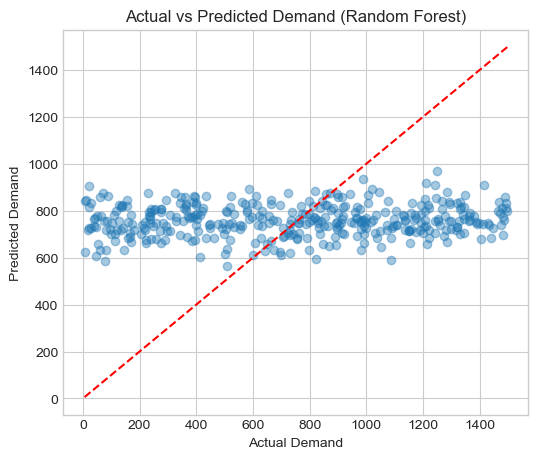

In [29]:
plt.figure(figsize=(6,5))
plt.scatter(y_test_fc, rf_pred_fc, alpha=0.4)
mn, mx = y_test_fc.min(), y_test_fc.max()
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")
plt.title("Actual vs Predicted Demand (Random Forest)")
plt.show()

## Training Final Model on FULL DATA

In [32]:
rf_fc.fit(X_fc, y_fc)

RandomForestRegressor(max_depth=8, n_estimators=200, random_state=42)

## Creating Future Data

In [34]:
# Get last available date per product
last_data = sales_decoded.sort_values('full_date').groupby('product_key').tail(1)

future_rows = []

forecast_horizon = 3  # next 3 months

for _, row in last_data.iterrows():
    for i in range(1, forecast_horizon+1):
        future_date = row['full_date'] + pd.DateOffset(months=i)

        future_rows.append({
            'product_key': row['product_key'],
            'year': future_date.year,
            'month': future_date.month,
            'quarter': (future_date.month-1)//3 + 1,
            'demand_lag1': row['historical_demand'],   # last known demand
            'demand_roll3': row['demand_roll3']        # last rolling avg
        })

future_df = pd.DataFrame(future_rows)

print("Future data created:", future_df.shape)

Future data created: (90, 6)


## Predicting Future Demand

In [38]:
future_X = future_df[features_uc1]

future_df['forecast_demand'] = rf_fc.predict(future_X)

print(future_df.head())

   product_key  year  month  quarter  demand_lag1  demand_roll3  \
0           16  2024      7        3         1332    880.333333   
1           16  2024      8        3         1332    880.333333   
2           16  2024      9        3         1332    880.333333   
3            2  2024      8        3         1146   1176.000000   
4            2  2024      9        3         1146   1176.000000   

   forecast_demand  
0       766.752785  
1       748.425919  
2       745.629753  
3       867.733101  
4       869.906381  


### Exporting Evaluation File (Actual vs Predicted)

In [41]:

fc_test_df = sales_decoded.iloc[split_idx:].copy()

fc_test_df['predicted_demand'] = rf_pred_fc.round(0).astype(int)

export_eval = fc_test_df[
    ['product_key','full_date','year','month','quarter',
     'historical_demand','predicted_demand']
].copy()

export_eval.rename(columns={'full_date':'date'}, inplace=True)

export_eval.to_csv('phase7_demand_forecast_eval.csv', index=False)

print(f"Saved eval file — {len(export_eval):,} rows")
print(export_eval.head(3))

Saved eval file — 382 rows
      product_key       date  year  month  quarter  historical_demand  \
1600           24 2024-03-19  2024      3        1               1190   
1601           24 2024-04-23  2024      4        2                762   
1602           24 2024-05-22  2024      5        2               1494   

      predicted_demand  
1600               719  
1601               747  
1602               811  


## Exporting Future Forecast

In [44]:
# Create proper date column
future_df['date'] = pd.to_datetime(
    future_df[['year','month']].assign(day=1)
)

# Round values
future_df['forecast_demand'] = future_df['forecast_demand'].round(0).astype(int)

export_future = future_df[
    ['product_key','date','year','month','forecast_demand']
].copy()

export_future.to_csv('phase7_demand_forecast_future.csv', index=False)

print(f"Saved future forecast — {len(export_future):,} rows")
print(export_future.head(3))

Saved future forecast — 90 rows
   product_key       date  year  month  forecast_demand
0           16 2024-07-01  2024      7              767
1           16 2024-08-01  2024      8              748
2           16 2024-09-01  2024      9              746


---
## Use Case 2: Supplier Delay Prediction (Classification)

**Goal:** Predict whether an order will arrive late using decoded purchase fact table.


## Features

In [49]:
#Selecting Features (avoid data leakage)
features_uc2 = ['product_key','supplier_key','quantity']
delay_df = purchase_decoded[features_uc2 + ['delay_flag']].dropna()


print("Class distribution:")
for k, v in delay_df['delay_flag'].value_counts().items():
    print(f"{'Delayed' if k==1 else 'On Time'}: {v} ({v/len(delay_df)*100:.1f}%)")

Class distribution:
Delayed: 576 (72.5%)
On Time: 219 (27.5%)


## Train/Test Split

In [52]:
#Split Data
X_dl = delay_df[features_uc2]
y_dl = delay_df['delay_flag']

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_dl, y_dl, test_size=0.2, random_state=42, stratify=y_dl)



## Models

In [55]:
#Train Models
#Logistic Regression
lr_dl = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_dl.fit(X_train_dl, y_train_dl)

# Random Forest(main model)
rf_dl = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_dl.fit(X_train_dl, y_train_dl)

#Predictions
lr_pred_dl = lr_dl.predict(X_test_dl)

rf_pred_dl = rf_dl.predict(X_test_dl)
rf_prob_dl = rf_dl.predict_proba(X_test_dl)[:, 1]




## Evaluation

In [57]:
# Evaluation
print("\n" + "="*50)
print("MODEL RESULTS — SUPPLIER DELAY PREDICTION")
print("="*50)

print(f"Logistic Regression Accuracy: {accuracy_score(y_test_dl, lr_pred_dl):.4f}")
print(f"Random Forest Accuracy     : {accuracy_score(y_test_dl, rf_pred_dl):.4f}")

print("\nClassification Report (Random Forest):")
print(classification_report(y_test_dl, rf_pred_dl, target_names=['On Time','Delayed']))


MODEL RESULTS — SUPPLIER DELAY PREDICTION
Logistic Regression Accuracy: 0.4465
Random Forest Accuracy     : 0.5786

Classification Report (Random Forest):
              precision    recall  f1-score   support

     On Time       0.26      0.27      0.26        44
     Delayed       0.71      0.70      0.70       115

    accuracy                           0.58       159
   macro avg       0.48      0.48      0.48       159
weighted avg       0.59      0.58      0.58       159



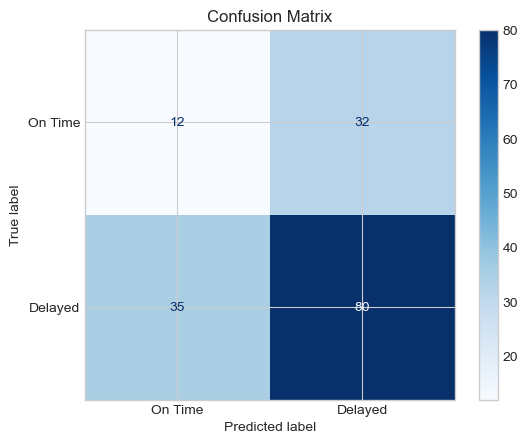

In [59]:
#Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test_dl, rf_pred_dl),
    display_labels=['On Time','Delayed']
).plot(cmap='Blues')

plt.title("Confusion Matrix")
plt.show()


## EXPORTING SUPPLIER DELAY RISK ( for PHASE 7)

In [62]:
delay_export = X_test_dl.copy().reset_index(drop=True)

# Add predictions
delay_export['actual_delay_flag']    = y_test_dl.values
delay_export['predicted_delay_flag'] = rf_pred_dl
delay_export['delay_probability']    = rf_prob_dl.round(4)

# Risk categorization
delay_export['risk_label'] = np.where(
    delay_export['delay_probability'] >= 0.7, 'High Risk',
    np.where(delay_export['delay_probability'] >= 0.4, 'Medium Risk', 'Low Risk')
)

# Readable labels
delay_export['predicted_status'] = delay_export['predicted_delay_flag'].map({
    0:'On Time', 1:'Delayed'
})

delay_export['actual_status'] = delay_export['actual_delay_flag'].map({
    0:'On Time', 1:'Delayed'
})

# Add supplier details
delay_export = delay_export.merge(
    dim_supplier[['supplier_key','supplier_id','supplier_name','rating']],
    on='supplier_key', how='left'
)

# Save file
delay_export.to_csv('phase7_supplier_delay.csv', index=False)

print(f"\nSaved phase7_supplier_delay.csv — {len(delay_export):,} rows")

print("\nRisk Distribution:")
print(delay_export['risk_label'].value_counts())

print("\nSample Output:")
print(delay_export[['supplier_name','quantity','delay_probability','predicted_status','risk_label']].head())


Saved phase7_supplier_delay.csv — 159 rows

Risk Distribution:
risk_label
High Risk      102
Low Risk        31
Medium Risk     26
Name: count, dtype: int64

Sample Output:
  supplier_name  quantity  delay_probability predicted_status risk_label
0   Supplier_10       435              0.965          Delayed  High Risk
1    Supplier_2        14              0.310          On Time   Low Risk
2    Supplier_3       307              0.925          Delayed  High Risk
3    Supplier_3       341              0.930          Delayed  High Risk
4    Supplier_4        30              0.365          On Time   Low Risk


---
## Use Case 3: Stock-Out Risk Prediction (Classification)

**Goal:** Predict which SKU-warehouse combinations are at stockout risk using enriched inventory data.


In [67]:
# Step 1: Features
features_uc3 = [
    'stock_ratio','days_of_cover','avg_lead_time',
    'avg_demand','demand_std','warehouse_key','supplier_key'
]

stock_df = inventory_decoded[features_uc3 + ['stockout_flag']].dropna()

print("Stockout distribution:")
for k, v in stock_df['stockout_flag'].value_counts().items():
    print(f"{'At Risk' if k==1 else 'Safe'}: {v} ({v/len(stock_df)*100:.1f}%)")

Stockout distribution:
Safe: 106 (88.3%)
At Risk: 14 (11.7%)


In [69]:
# Step 2: Split
X_st = stock_df[features_uc3]
y_st = stock_df['stockout_flag']

X_train_st, X_test_st, y_train_st, y_test_st = train_test_split(
    X_st, y_st, test_size=0.2, random_state=42, stratify=y_st)

In [71]:
# Step 3: Model
rf_st = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_st.fit(X_train_st, y_train_st)

rf_pred_st = rf_st.predict(X_test_st)
rf_prob_st = rf_st.predict_proba(X_test_st)[:, 1]

In [72]:
# Step 4: Evaluation
print("\nAccuracy:", accuracy_score(y_test_st, rf_pred_st))
print("\nClassification Report:")
print(classification_report(y_test_st, rf_pred_st, target_names=['Safe','At Risk']))


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00        21
     At Risk       1.00      1.00      1.00         3

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24



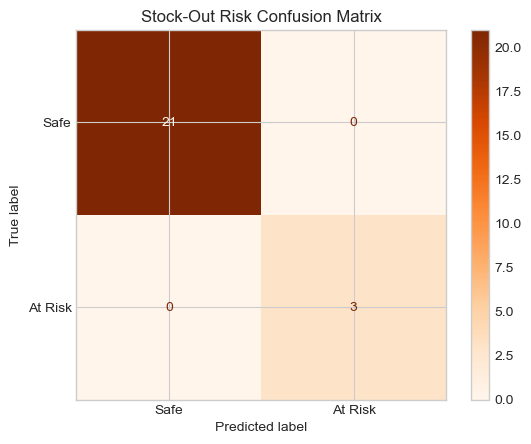

In [75]:
# Step 5: Confusion Matrix
ConfusionMatrixDisplay(
    confusion_matrix(y_test_st, rf_pred_st),
    display_labels=['Safe','At Risk']
).plot(cmap='Oranges')

plt.title("Stock-Out Risk Confusion Matrix")
plt.show()

## EXPORTING STOCK-OUT RISK (for PHASE 7)

In [78]:
# Predict for FULL dataset (important)
full_prob_st = rf_st.predict_proba(X_st)[:, 1]

stock_export = inventory_decoded.loc[X_st.index].copy()

stock_export['stockout_probability'] = full_prob_st.round(4)

# Risk segmentation (consistent with UC2)
stock_export['risk_label'] = np.where(
    stock_export['stockout_probability'] >= 0.7, 'High Risk',
    np.where(stock_export['stockout_probability'] >= 0.4, 'Medium Risk', 'Low Risk')
)

# Final columns
export_cols = [
    'product_key','warehouse_key','supplier_name',
    'current_stock','reorder_level','stock_ratio','days_of_cover',
    'avg_lead_time','avg_demand','stockout_probability','risk_label','stockout_flag'
]

stock_export = stock_export[export_cols]

# Save
stock_export.to_csv('phase7_stockout_risk.csv', index=False)

print(f"\nSaved phase7_stockout_risk.csv — {len(stock_export):,} rows")

print("\nRisk Distribution:")
print(stock_export['risk_label'].value_counts())

print("\nSample Output:")
print(stock_export.head(4))


Saved phase7_stockout_risk.csv — 120 rows

Risk Distribution:
risk_label
Low Risk       106
High Risk       13
Medium Risk      1
Name: count, dtype: int64

Sample Output:
   product_key  warehouse_key supplier_name  current_stock  reorder_level  \
0            1              1    Supplier_9            867            191   
1            1              2    Supplier_9           1161            212   
2            1              3    Supplier_9            386            160   
3            1              4    Supplier_9            613             66   

   stock_ratio  days_of_cover  avg_lead_time  avg_demand  \
0     4.539267       1.110029      11.727273  781.060606   
1     5.476415       1.486440      11.727273  781.060606   
2     2.412500       0.494200      11.727273  781.060606   
3     9.287879       0.784830      11.727273  781.060606   

   stockout_probability risk_label  stockout_flag  
0                 0.000   Low Risk              0  
1                 0.005   Low Risk  